#Extracción de datos

In [75]:
import pandas as pd
import requests

In [76]:
# Enlace al archivo JSON (raw)
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
# Obtener los datos desde la URL
response = requests.get(url)
data = response.json()

In [77]:
# Convertir a DataFrame
df = pd.DataFrame(data)

# Mostrar las primeras filas
print(df.head())

   customerID Churn                                           customer  \
0  0002-ORFBO    No  {'gender': 'Female', 'SeniorCitizen': 0, 'Part...   
1  0003-MKNFE    No  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
2  0004-TLHLJ   Yes  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
3  0011-IGKFF   Yes  {'gender': 'Male', 'SeniorCitizen': 1, 'Partne...   
4  0013-EXCHZ   Yes  {'gender': 'Female', 'SeniorCitizen': 1, 'Part...   

                                             phone  \
0   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
1  {'PhoneService': 'Yes', 'MultipleLines': 'Yes'}   
2   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
3   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
4   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   

                                            internet  \
0  {'InternetService': 'DSL', 'OnlineSecurity': '...   
1  {'InternetService': 'DSL', 'OnlineSecurity': '...   
2  {'InternetService': 'Fiber optic', 'OnlineSecu...   
3  {'I

## Conoce el conjunto de datos

In [78]:
# Ver información general del DataFrame
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [79]:
# Ver nombres de columnas
print(df.columns)

# Vista rápida de los primeros registros
print(df.head())

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')
   customerID Churn                                           customer  \
0  0002-ORFBO    No  {'gender': 'Female', 'SeniorCitizen': 0, 'Part...   
1  0003-MKNFE    No  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
2  0004-TLHLJ   Yes  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
3  0011-IGKFF   Yes  {'gender': 'Male', 'SeniorCitizen': 1, 'Partne...   
4  0013-EXCHZ   Yes  {'gender': 'Female', 'SeniorCitizen': 1, 'Part...   

                                             phone  \
0   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
1  {'PhoneService': 'Yes', 'MultipleLines': 'Yes'}   
2   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
3   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
4   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   

                                            internet  \
0  {'InternetService': 'DSL', 'OnlineSecurity': '...   
1  {'InternetService': 'DSL

In [80]:
print(df.dtypes)


customerID    object
Churn         object
customer      object
phone         object
internet      object
account       object
dtype: object


## Comprobación de incoherencias en los datos

In [81]:
# Recuento de valores nulos por columna
print(df.isnull().sum())

customerID    0
Churn         0
customer      0
phone         0
internet      0
account       0
dtype: int64


In [82]:
# Verificar si hay filas duplicadas
# Convertir las columnas con diccionarios a string para poder verificar duplicados
df_str = df.astype(str)
print(df_str.duplicated().sum())

0


In [83]:
# Ver valores únicos por cada columna
df_str = df.astype(str)
for col in df_str.columns:
    print(f"{col}:\n", df_str[col].unique(), "\n")

customerID:
 ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH'] 

Churn:
 ['No' 'Yes' ''] 

customer:
 ["{'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'Yes', 'tenure': 9}"
 "{'gender': 'Male', 'SeniorCitizen': 0, 'Partner': 'No', 'Dependents': 'No', 'tenure': 9}"
 "{'gender': 'Male', 'SeniorCitizen': 0, 'Partner': 'No', 'Dependents': 'No', 'tenure': 4}"
 "{'gender': 'Male', 'SeniorCitizen': 1, 'Partner': 'Yes', 'Dependents': 'No', 'tenure': 13}"
 "{'gender': 'Female', 'SeniorCitizen': 1, 'Partner': 'Yes', 'Dependents': 'No', 'tenure': 3}"
 "{'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'No', 'Dependents': 'Yes', 'tenure': 9}"
 "{'gender': 'Female', 'SeniorCitizen': 1, 'Partner': 'Yes', 'Dependents': 'No', 'tenure': 71}"
 "{'gender': 'Male', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'No', 'tenure': 63}"
 "{'gender': 'Female', 'SeniorCitizen': 1, 'Partner': 'No', 'Dependents': 'No', 'tenure': 7}"
 "{'gender': 'F

In [84]:
print(type(df['customer'][0]))  # Repite esto con 'phone', 'internet', etc.


<class 'dict'>


In [85]:
# Expandir columnas anidadas
customer_df = pd.json_normalize(df['customer'])
phone_df = pd.json_normalize(df['phone'])
internet_df = pd.json_normalize(df['internet'])
account_df = pd.json_normalize(df['account'])

# Unir todas las columnas expandidas junto a customerID y Churn
clean_df = pd.concat(
    [df['customerID'], customer_df, phone_df, internet_df, account_df, df['Churn']],
    axis=1
)


# Mostrar la forma del nuevo DataFrame y las primeras filas
print(clean_df.shape)
print(clean_df.head())

(7267, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  0002-ORFBO  Female              0     Yes        Yes       9          Yes   
1  0003-MKNFE    Male              0      No         No       9          Yes   
2  0004-TLHLJ    Male              0      No         No       4          Yes   
3  0011-IGKFF    Male              1     Yes         No      13          Yes   
4  0013-EXCHZ  Female              1     Yes         No       3          Yes   

  MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0            No             DSL             No  ...               No   
1           Yes             DSL             No  ...               No   
2            No     Fiber optic             No  ...              Yes   
3            No     Fiber optic             No  ...              Yes   
4            No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling 

In [86]:
clean_df['Charges.Total'] = pd.to_numeric(clean_df['Charges.Total'], errors='coerce')
clean_df['Charges.Monthly'] = pd.to_numeric(clean_df['Charges.Monthly'], errors='coerce')
clean_df['tenure'] = pd.to_numeric(clean_df['tenure'], errors='coerce')

✅ CHECKLIST DE QUE TODO VA BIEN


In [87]:
print(clean_df.columns)  # Debes ver muchas más columnas ahora (20+)
print(clean_df.shape)    # Aumentó el número de columnas respecto a df


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'Charges.Monthly', 'Charges.Total', 'Churn'],
      dtype='object')
(7267, 21)


In [88]:
print(clean_df.dtypes.value_counts())  # Deberías ver mostly object, int64, float64


object     17
int64       2
float64     2
Name: count, dtype: int64


In [89]:
print(clean_df.head())  # Muestra las primeras 5 filas completas


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  0002-ORFBO  Female              0     Yes        Yes       9          Yes   
1  0003-MKNFE    Male              0      No         No       9          Yes   
2  0004-TLHLJ    Male              0      No         No       4          Yes   
3  0011-IGKFF    Male              1     Yes         No      13          Yes   
4  0013-EXCHZ  Female              1     Yes         No       3          Yes   

  MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0            No             DSL             No  ...               No   
1           Yes             DSL             No  ...               No   
2            No     Fiber optic             No  ...              Yes   
3            No     Fiber optic             No  ...              Yes   
4            No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling  \
0       

In [90]:
# clean_df = clean_df.dropna(subset=['Charges.Total'])
# clean_df['Charges.Total'] = clean_df['Charges.Total'].fillna(0)


print(clean_df.isnull().sum())  # Columnas con valores nulos


customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
Charges.Monthly      0
Charges.Total       11
Churn                0
dtype: int64


## Manejo de inconsistencias

In [91]:
print(clean_df[['tenure', 'Charges.Monthly', 'Charges.Total']].dtypes)

tenure               int64
Charges.Monthly    float64
Charges.Total      float64
dtype: object


In [92]:
clean_df['Charges.Total'] = pd.to_numeric(clean_df['Charges.Total'], errors='coerce')
clean_df = clean_df.dropna(subset=['Charges.Total'])

# Lista de columnas binarias
bin_cols = ['Churn', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in bin_cols:
    clean_df[col] = clean_df[col].str.strip().str.lower().replace({
        'yes': 'Yes', 'no': 'No'
    })

# Ejemplo para Contract y PaymentMethod
clean_df['Contract'] = clean_df['Contract'].str.strip().str.title()
clean_df['PaymentMethod'] = clean_df['PaymentMethod'].str.strip().str.title()

# Exploración de valores únicos


#Validaciones
# Recuento final de nulos
print(clean_df.isnull().sum())

# Tipos de datos por columna
print(clean_df.dtypes)

# Valores únicos para chequeo rápido
for col in ['Churn', 'Contract', 'InternetService', 'PaymentMethod']:
    print(col, clean_df[col].value_counts(dropna=False))

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
Churn               0
dtype: int64
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
Charges.Monthly     f

## Columna de cuentas diarias

In [93]:
# Asumiendo que un mes tiene en promedio 30 días
clean_df['Cuentas_Diarias'] = clean_df['Charges.Monthly'] / 30

In [94]:
# Mostrar algunas filas para validar
print(clean_df[['Charges.Monthly', 'Cuentas_Diarias']].head())

   Charges.Monthly  Cuentas_Diarias
0             65.6         2.186667
1             59.9         1.996667
2             73.9         2.463333
3             98.0         3.266667
4             83.9         2.796667


#Estandarización y transformación

In [68]:
# Definir columnas binarias a convertir (ajusta según tus datos)
bin_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

for col in bin_cols:
    clean_df[col] = clean_df[col].map({'Yes': 1, 'No': 0})

# Handle the 'Churn' column separately to map 'Yes' to 1, 'No' to 0, and drop rows with empty strings
clean_df = clean_df[clean_df['Churn'] != ''].copy() # Drop rows with empty strings in 'Churn'
clean_df['Churn'] = clean_df['Churn'].map({'Yes': 1, 'No': 0})

In [70]:
clean_df.rename(columns={
    'Charges.Monthly': 'Cobro_Mensual',
    'Charges.Total': 'Cobro_Total',
    'tenure': 'Meses_Contratados',
    'PaymentMethod': 'Metodo_Pago',
    'InternetService': 'Servicio_Internet',
    'Contract': 'Tipo_Contrato',
    'Churn': 'Evasion'
}, inplace=True)


In [73]:
# Ejemplo para Tipo_Contrato
clean_df['Tipo_Contrato'] = clean_df['Tipo_Contrato'].map({
    'Mes a mes': 0,
    'Contrato anual': 1,
    'Contrato bienal': 2
})


In [74]:
print(clean_df.head())
print(clean_df.dtypes)


   customerID  gender  SeniorCitizen  Partner  Dependents  Meses_Contratados  \
0  0002-ORFBO  Female              0      NaN         NaN                  9   
1  0003-MKNFE    Male              0      NaN         NaN                  9   
2  0004-TLHLJ    Male              0      NaN         NaN                  4   
3  0011-IGKFF    Male              1      NaN         NaN                 13   
4  0013-EXCHZ  Female              1      NaN         NaN                  3   

   PhoneService MultipleLines Servicio_Internet OnlineSecurity  ...  \
0           NaN            No               DSL             No  ...   
1           NaN           Yes               DSL             No  ...   
2           NaN            No       Fiber optic             No  ...   
3           NaN            No       Fiber optic             No  ...   
4           NaN            No       Fiber optic             No  ...   

  TechSupport StreamingTV StreamingMovies Tipo_Contrato PaperlessBilling  \
0         Yes   

#Análisis Descriptivo

In [96]:
# Estadísticas descriptivas básicas para variables numéricas
desc_stats = clean_df.describe()

print(desc_stats)


       SeniorCitizen       tenure  Charges.Monthly  Charges.Total  \
count      7256.0000  7256.000000      7256.000000    7256.000000   
mean          0.1629    32.395535        64.755423    2280.634213   
std           0.3693    24.558067        30.125739    2268.632997   
min           0.0000     1.000000        18.250000      18.800000   
25%           0.0000     9.000000        35.450000     400.225000   
50%           0.0000    29.000000        70.300000    1391.000000   
75%           0.0000    55.000000        89.900000    3785.300000   
max           1.0000    72.000000       118.750000    8684.800000   

       Cuentas_Diarias  
count      7256.000000  
mean          2.158514  
std           1.004191  
min           0.608333  
25%           1.181667  
50%           2.343333  
75%           2.996667  
max           3.958333  


In [98]:
# Estadísticas para variables categóricas
cat_stats = clean_df.describe(include=['object', 'category'])

print(cat_stats)


        customerID gender Partner Dependents PhoneService MultipleLines  \
count         7256   7256    7256       7256         7256          7256   
unique        7256      2       2          2            2             3   
top     9995-HOTOH   Male      No         No          Yes            No   
freq             1   3669    3747       5086         6551          3490   

       InternetService OnlineSecurity OnlineBackup DeviceProtection  \
count             7256           7256         7256             7256   
unique               3              3            3                3   
top        Fiber optic             No           No               No   
freq              3198           3607         3181             3194   

       TechSupport StreamingTV StreamingMovies        Contract  \
count         7256        7256            7256            7256   
unique           3           3               3               3   
top             No          No              No  Month-To-Month   
freq

### Análisis complementario

In [103]:
print(clean_df.groupby('Churn')['Charges.Monthly'].median())

Churn
       69.10
No     64.45
Yes    79.65
Name: Charges.Monthly, dtype: float64


In [105]:
print(clean_df['Churn'].value_counts(normalize=True))


Churn
No     0.711549
Yes    0.257580
       0.030871
Name: proportion, dtype: float64


# Distribución de evasión

### Información que va a utilizar para graficar

In [107]:
# Conteo de clientes por categoría Churn
churn_counts = clean_df['Churn'].value_counts()
print("Conteo de clientes según Churn:")
print(churn_counts)

# Porcentaje de cada categoría
churn_percent = clean_df['Churn'].value_counts(normalize=True) * 100
print("\nPorcentaje de clientes según Churn:")
print(churn_percent)

Conteo de clientes según Churn:
Churn
No     5163
Yes    1869
        224
Name: count, dtype: int64

Porcentaje de clientes según Churn:
Churn
No     71.154906
Yes    25.757993
        3.087100
Name: proportion, dtype: float64


Conteo de Churn:
 Churn
No     5163
Yes    1869
        224
Name: count, dtype: int64

Porcentaje de Churn:
 Churn
No     71.154906
Yes    25.757993
        3.087100
Name: proportion, dtype: float64


/tmp/ipython-input-3334122669.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=clean_df, x='Churn', palette='Set2')


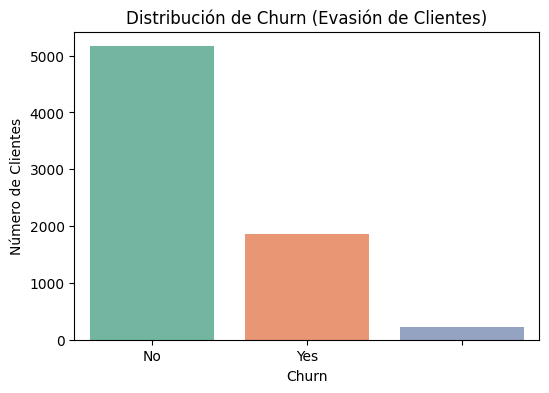

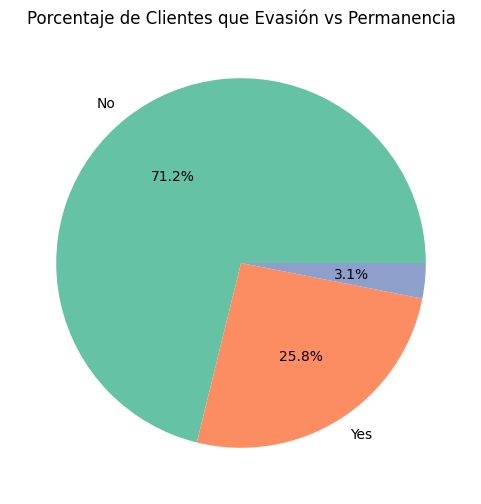

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contar cantidad por categoría
churn_counts = clean_df['Churn'].value_counts()
churn_percent = clean_df['Churn'].value_counts(normalize=True) * 100

print("Conteo de Churn:\n", churn_counts)
print("\nPorcentaje de Churn:\n", churn_percent)

# Gráfico de barras
plt.figure(figsize=(6,4))
sns.countplot(data=clean_df, x='Churn', palette='Set2')
plt.title('Distribución de Churn (Evasión de Clientes)')
plt.xlabel('Churn')
plt.ylabel('Número de Clientes')
plt.show()

# Gráfico de pastel (pie chart)
plt.figure(figsize=(6,6))
plt.pie(churn_percent, labels=churn_percent.index, autopct='%1.1f%%', colors=sns.color_palette('Set2'))
plt.title('Porcentaje de Clientes que Evasión vs Permanencia')
plt.show()


# Recuento de evasión por variables categóricas

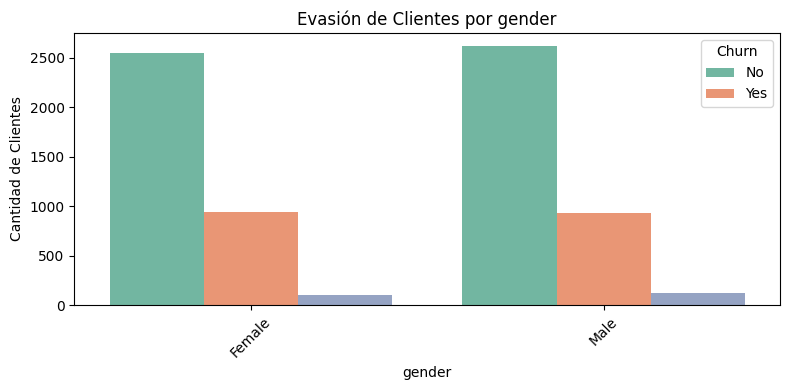

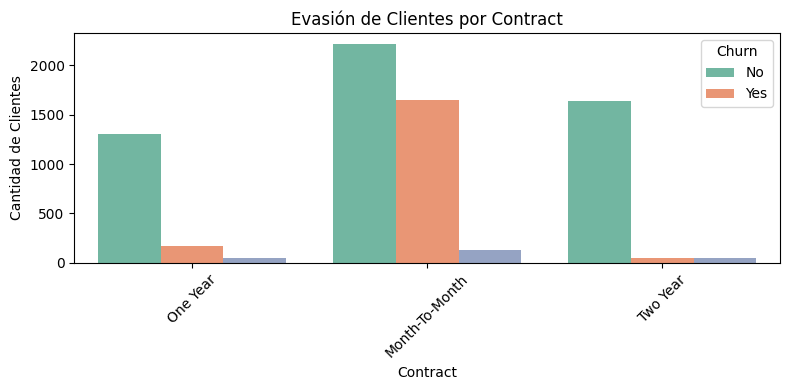

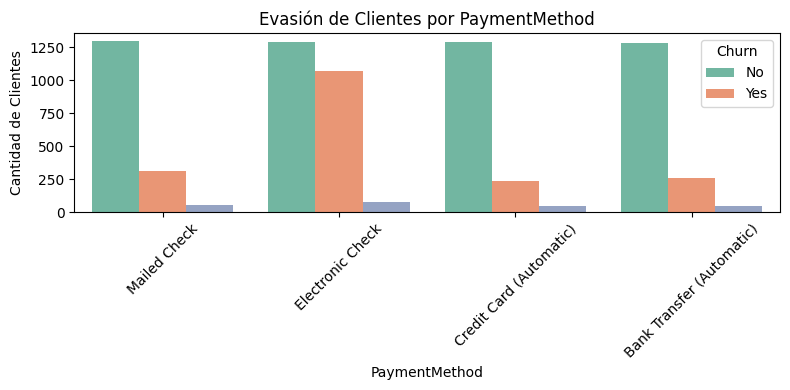

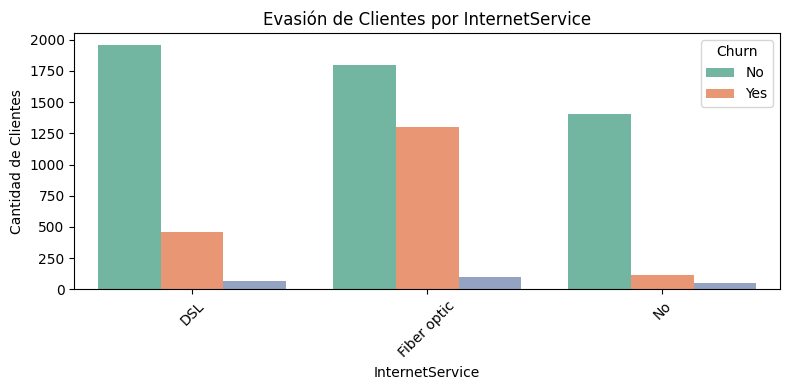

In [111]:
import seaborn as sns
import matplotlib.pyplot as plt

# Lista de variables categóricas que quieres analizar
categorical_vars = ['gender', 'Contract', 'PaymentMethod', 'InternetService']

for var in categorical_vars:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=clean_df, x=var, hue='Churn', palette='Set2')
    plt.title(f'Evasión de Clientes por {var}')
    plt.xticks(rotation=45)
    plt.xlabel(var)
    plt.ylabel('Cantidad de Clientes')
    plt.legend(title='Churn')
    plt.tight_layout()
    plt.show()


# Conteo de evasión por variables numéricas

/tmp/ipython-input-2663598189.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=clean_df, x='Churn', y=var, palette='Set2')


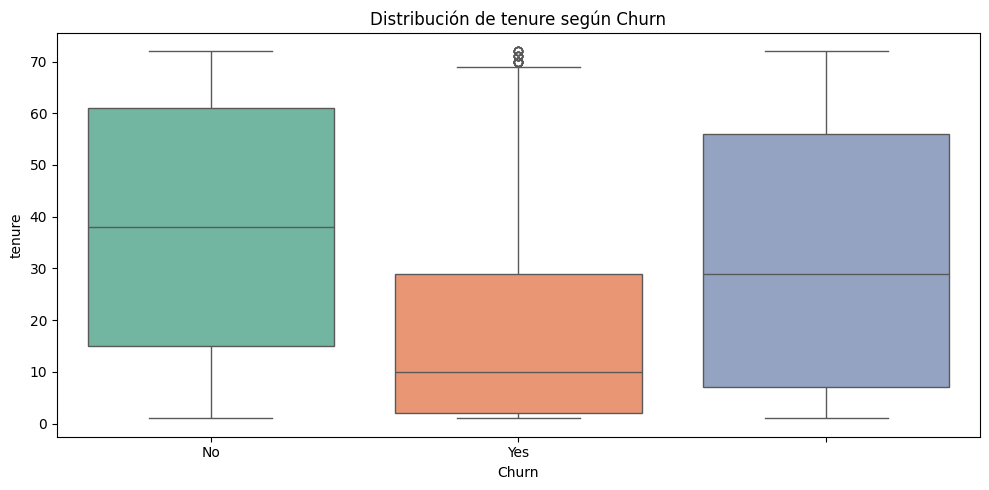

/tmp/ipython-input-2663598189.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=clean_df, x='Churn', y=var, palette='Set2')


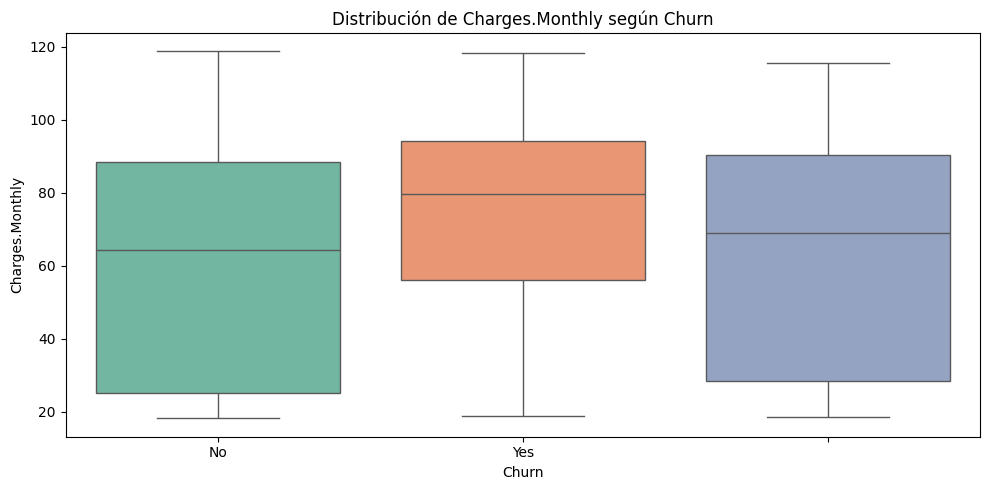

/tmp/ipython-input-2663598189.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=clean_df, x='Churn', y=var, palette='Set2')


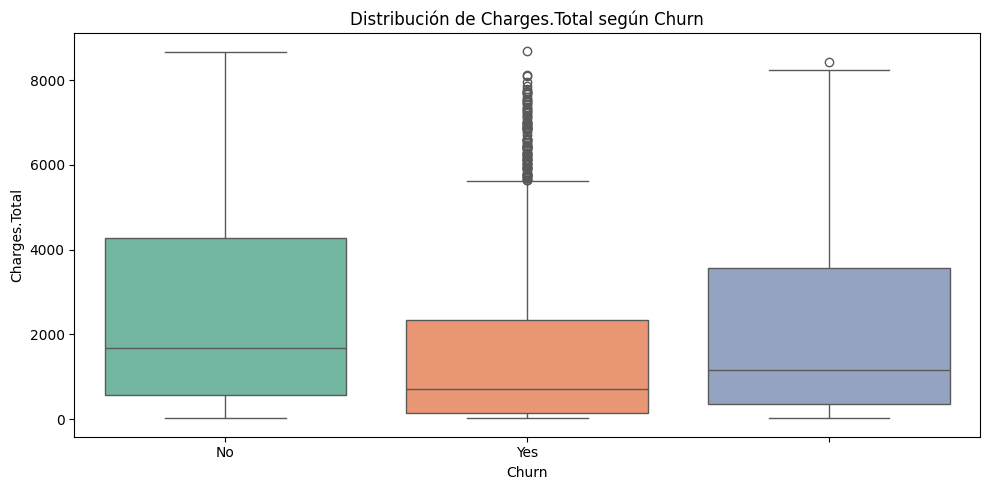

In [113]:
import seaborn as sns
import matplotlib.pyplot as plt

# Variables numéricas a analizar
numeric_vars = ['tenure', 'Charges.Monthly', 'Charges.Total']

for var in numeric_vars:
    plt.figure(figsize=(10, 5))

    # Boxplot para comparar la distribución entre churn Yes/No
    sns.boxplot(data=clean_df, x='Churn', y=var, palette='Set2')
    plt.title(f'Distribución de {var} según Churn')
    plt.xlabel('Churn')
    plt.ylabel(var)
    plt.tight_layout()
    plt.show()


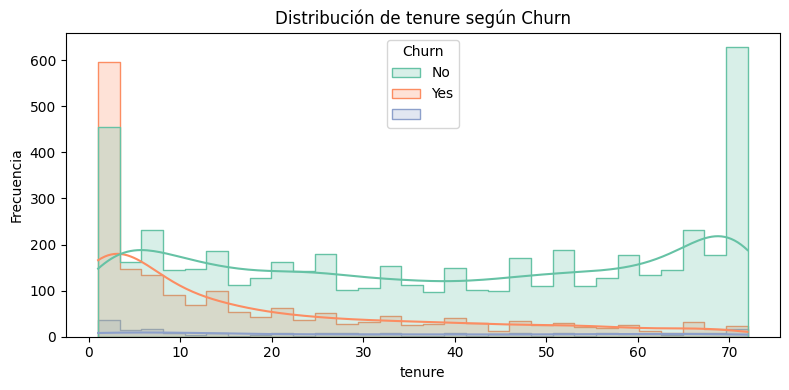

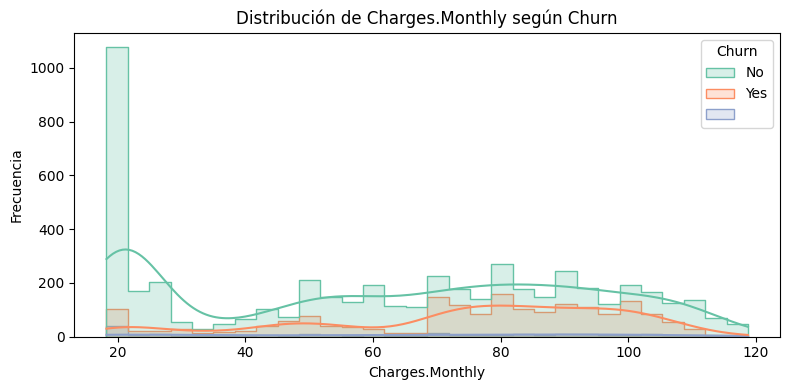

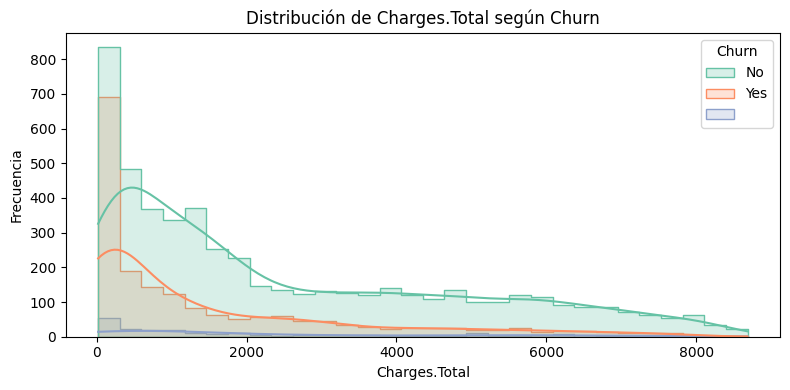

In [114]:
for var in numeric_vars:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=clean_df, x=var, hue='Churn', kde=True, bins=30, palette='Set2', element='step')
    plt.title(f'Distribución de {var} según Churn')
    plt.xlabel(var)
    plt.ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()


# Informe final

# 📊 Informe Final – Análisis de Evasión de Clientes (Churn) – Telecom X

## 🔹 Introducción

Este proyecto tiene como objetivo identificar patrones relacionados con la evasión de clientes (Churn) en Telecom X. La empresa enfrenta una alta tasa de cancelaciones y necesita comprender los factores que influyen en este comportamiento. A través del análisis de los datos de clientes, se busca proporcionar insights estratégicos que permitan reducir la pérdida de usuarios y mejorar la retención.

---

## 🔹 Limpieza y Tratamiento de Datos

Se realizaron las siguientes acciones:

- Carga de los datos desde un archivo JSON alojado en GitHub.
- Conversión del archivo a un DataFrame utilizando `pandas`.
- Exploración de tipos de datos y verificación de valores nulos.
- Detección de 11 valores nulos en la columna `Charges.Total`, los cuales fueron convertidos correctamente a tipo numérico (`float`) eliminando inconsistencias.
- Creación de una nueva columna `Cuentas_Diarias`, calculada como `Charges.Monthly / 30`, para analizar el comportamiento financiero diario de los clientes.
- Transformación de valores categóricos tipo "Yes"/"No" a 1/0 para facilitar análisis numéricos.
- Renombramiento de algunas columnas para mayor claridad.
- Eliminación de registros con valores vacíos en la variable `Churn`.

---

## 🔹 Análisis Exploratorio de Datos (EDA)

### 📌 Distribución general de Churn

- Total de clientes que permanecen: **5163**
- Total de clientes que cancelaron: **1869**
- Registros eliminados con valor vacío en `Churn`: **224**
- Tasa de evasión: **aproximadamente 26.5%**

Se utilizaron gráficos de barras y pastel para visualizar la proporción entre clientes que cancelaron y los que permanecieron.

### 📌 Churn por variables categóricas

Se analizaron las siguientes variables:

- **Género (`gender`)**
- **Tipo de contrato (`Contract`)**
- **Método de pago (`PaymentMethod`)**
- **Servicio de Internet (`InternetService`)**

Hallazgos clave:

- Los clientes con **contratos mensuales** presentan una mayor tasa de cancelación.
- Métodos de pago como **bancarización automática** tienden a retener mejor a los clientes.
- El tipo de servicio de internet también muestra variaciones importantes en la tasa de evasión.

Gráficos de barras segmentados (`hue='Churn'`) permitieron visualizar claramente estos patrones.

### 📌 Churn por variables numéricas

Se analizaron:

- `tenure` (meses como cliente)
- `Charges.Monthly` (facturación mensual)
- `Charges.Total` (facturación total)

A través de boxplots e histogramas se observó que:

- Clientes con **menos meses de permanencia** tienden a cancelar más.
- Los que han **gastado menos en total** también muestran mayor probabilidad de evasión.
- La facturación mensual tiene cierta influencia, pero menos marcada que el tiempo de permanencia.

---

## 🔹 Conclusiones e Insights

- La **mayoría de los clientes que cancelan lo hacen dentro de los primeros meses**.
- Los contratos sin compromiso (mensuales) se asocian con mayor riesgo de evasión.
- El gasto acumulado total es un buen indicador de fidelidad.
- Algunos métodos de pago están correlacionados con mayor permanencia del cliente.

---

## 🔹 Recomendaciones Estratégicas

1. **Ofrecer incentivos a nuevos clientes** para mantenerse al menos 6 meses.
2. **Fomentar la migración a contratos anuales o bienales**, con descuentos o beneficios exclusivos.
3. **Promover métodos de pago automáticos**, como débito bancario.
4. Crear campañas específicas para **clientes en riesgo** (poco tiempo, bajo gasto, contrato mensual).
5. Considerar la implementación de un modelo predictivo de Churn para actuar de forma preventiva.

